In [14]:
len(search_trend.index), len(set(search_trend.index))

(379, 379)

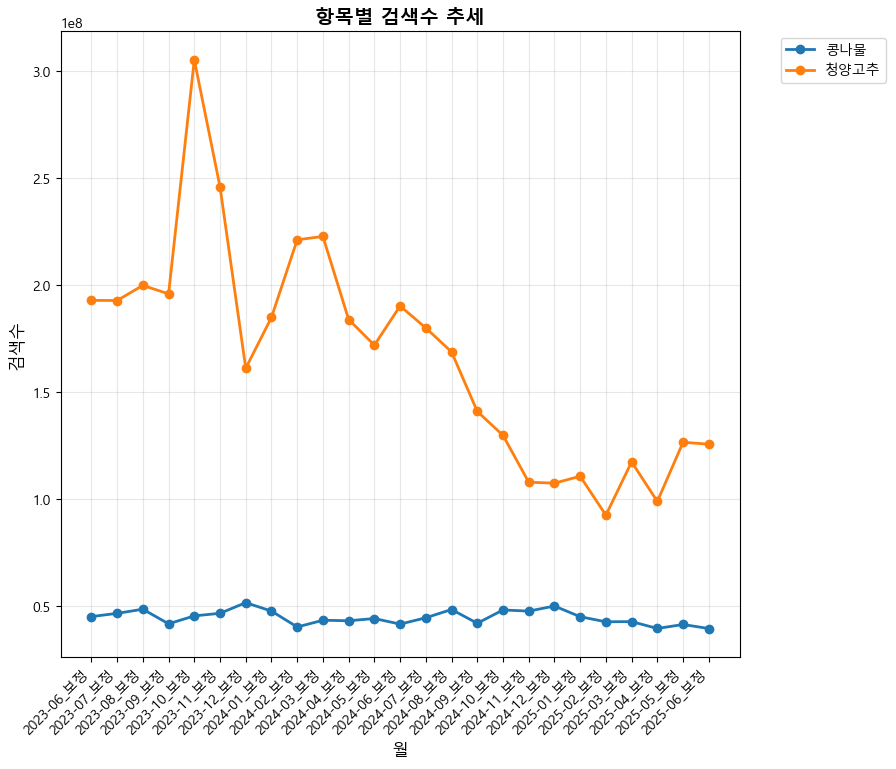

In [25]:
import pandas as pd
import numpy as np
import tkinter as tk
from tkinter import messagebox, ttk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# --- 한글 폰트 설정 ---
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# --- 경로 및 파일 설정 ---
recipe_file = "병합_레시피_포함매핑적용_380개메뉴포함.xlsx"
merged_file = "상세메뉴_통합결과_URL포함.xlsx"
output_file = "항목별_월별추세_계산결과.xlsx"

# --- 데이터 처리 ---
sheet_names = pd.ExcelFile(recipe_file).sheet_names
sheet1 = pd.read_excel(recipe_file, sheet_name=sheet_names[0], index_col=0)
sheet2 = pd.read_excel(recipe_file, sheet_name=sheet_names[1], index_col=0)
binary_matrix = pd.concat([sheet1, sheet2])
binary_matrix = binary_matrix.replace('-', np.nan)
binary_matrix = binary_matrix.notna().astype(int)

search_df = pd.read_excel(merged_file, sheet_name=0)
search_df.set_index("상세메뉴", inplace=True)
search_df = search_df.loc[~search_df.index.duplicated(keep='first')]

search_cols = search_df.columns[-75:-50]
adjust_cols = search_df.columns[-50:-25]
url_cols = search_df.columns[-25:]

search_trend = search_df[search_cols]
adjust_trend = search_df[adjust_cols]
url_trend = search_df[url_cols]

recipe_menus = set(binary_matrix.columns)
trend_menus = set(search_trend.index)
common_menus = sorted(recipe_menus & trend_menus)

binary_matrix_filtered = binary_matrix[common_menus]
search_trend = search_trend.loc[common_menus]
adjust_trend = adjust_trend.loc[common_menus]
url_trend = url_trend.loc[common_menus]

ingredient_search = binary_matrix_filtered @ search_trend.fillna(0)
ingredient_adjust = binary_matrix_filtered @ adjust_trend.fillna(0)
ingredient_url = binary_matrix_filtered @ url_trend.fillna(0)

with pd.ExcelWriter(output_file) as writer:
    ingredient_search.to_excel(writer, sheet_name="검색수_항목별_추세")
    ingredient_adjust.to_excel(writer, sheet_name="보정검색수_항목별_추세")
    ingredient_url.to_excel(writer, sheet_name="URL수_항목별_추세")

# --- 전역 변수 ---
current_data_type = 0  # 0: 검색수, 1: 보정검색수, 2: URL수
data_types = ["검색수", "보정검색수", "URL수"]
data_sources = [ingredient_search, ingredient_adjust, ingredient_url]

# --- 그래프 그리기 함수 ---
def plot_trends():
    selected = lb.curselection()
    if not selected:
        messagebox.showwarning("선택 오류", "항목을 1개 이상 선택하세요.")
        return
    if len(selected) > 5:
        messagebox.showwarning("선택 오류", "최대 5개까지만 선택할 수 있습니다.")
        return
    
    labels = [lb.get(i) for i in selected]
    current_data = data_sources[current_data_type]
    current_type_name = data_types[current_data_type]
    
    ax.clear()
    
    # 색상 팔레트 설정
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for i, label in enumerate(labels):
        color = colors[i % len(colors)]
        ax.plot(current_data.columns, current_data.loc[label], 
               label=f"{label}", marker='o', linewidth=2, color=color)
    
    ax.set_title(f"항목별 {current_type_name} 추세", fontsize=14, fontweight='bold')
    ax.set_xlabel("월", fontsize=12)
    ax.set_ylabel(current_type_name, fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # x축 레이블 회전
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    fig.tight_layout()
    canvas.draw()
    
    # 현재 표시 중인 데이터 타입 업데이트
    status_label.config(text=f"현재 표시: {current_type_name} ({len(labels)}개 항목 선택됨)")

# --- 데이터 타입 변경 함수 ---
def change_data_type(direction):
    global current_data_type
    current_data_type = (current_data_type + direction) % 3
    data_type_label.config(text=f"데이터 타입: {data_types[current_data_type]}")
    plot_trends()

def prev_data_type():
    change_data_type(-1)

def next_data_type():
    change_data_type(1)

# --- 선택 개수 확인 함수 ---
def on_selection_change(event):
    selected_count = len(lb.curselection())
    if selected_count > 5:
        # 선택이 5개를 초과하면 마지막 선택을 해제
        selections = list(lb.curselection())
        lb.selection_clear(selections[-1])
        selected_count = 5
        messagebox.showwarning("선택 제한", "최대 5개까지만 선택할 수 있습니다.")
    
    selection_count_label.config(text=f"선택된 항목: {selected_count}/5")

# --- UI 구성 ---
root = tk.Tk()
root.title("항목별 추세 시각화 (3종 데이터)")
root.geometry("1200x800")

# 왼쪽 프레임 (컨트롤)
left_frame = tk.Frame(root)
left_frame.pack(side='left', padx=10, pady=10, fill='y')

# 제목
tk.Label(left_frame, text="항목별 추세 분석", font=('Arial', 14, 'bold')).pack(pady=(0, 10))

# 데이터 타입 선택
data_type_frame = tk.Frame(left_frame)
data_type_frame.pack(pady=5, fill='x')

tk.Button(data_type_frame, text="◀ 이전", command=prev_data_type, width=8).pack(side='left')
data_type_label = tk.Label(data_type_frame, text=f"데이터 타입: {data_types[current_data_type]}", 
                          font=('Arial', 10, 'bold'))
data_type_label.pack(side='left', expand=True)
tk.Button(data_type_frame, text="다음 ▶", command=next_data_type, width=8).pack(side='right')

# 구분선
ttk.Separator(left_frame, orient='horizontal').pack(fill='x', pady=10)

# 항목 선택
tk.Label(left_frame, text="항목 선택 (최대 5개)", font=('Arial', 12)).pack()

selection_count_label = tk.Label(left_frame, text="선택된 항목: 0/5", fg='blue')
selection_count_label.pack(pady=5)

# 리스트박스와 스크롤바
listbox_frame = tk.Frame(left_frame)
listbox_frame.pack(fill='both', expand=True, pady=5)

scrollbar = tk.Scrollbar(listbox_frame)
scrollbar.pack(side='right', fill='y')

lb = tk.Listbox(listbox_frame, selectmode=tk.MULTIPLE, width=30, height=25, 
                yscrollcommand=scrollbar.set)
lb.pack(side='left', fill='both', expand=True)
scrollbar.config(command=lb.yview)

# 항목 추가
for item in ingredient_search.index:
    lb.insert(tk.END, item)

# 선택 변경 이벤트 바인딩
lb.bind('<<ListboxSelect>>', on_selection_change)

# 그래프 그리기 버튼
tk.Button(left_frame, text="그래프 그리기", command=plot_trends, 
          bg='lightblue', font=('Arial', 12, 'bold'), pady=5).pack(pady=10, fill='x')

# 상태 표시
status_label = tk.Label(left_frame, text="항목을 선택하고 그래프 그리기를 클릭하세요.", 
                       fg='green', wraplength=250)
status_label.pack(pady=5)

# 오른쪽 프레임 (그래프)
right_frame = tk.Frame(root)
right_frame.pack(side='right', fill='both', expand=True, padx=10, pady=10)

# 그래프
fig, ax = plt.subplots(figsize=(12, 8))
canvas = FigureCanvasTkAgg(fig, master=right_frame)
canvas.get_tk_widget().pack(fill='both', expand=True)

# 초기 메시지
ax.text(0.5, 0.5, '항목을 선택하고 그래프 그리기를 클릭하세요.\n\n◀ 이전 / 다음 ▶ 버튼으로 데이터 타입을 변경할 수 있습니다.', 
        horizontalalignment='center', verticalalignment='center', transform=ax.transAxes,
        fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

canvas.draw()

root.mainloop()

In [5]:
diff_df

,레시피에만 있는 상세메뉴,추세데이터에만 있는 상세메뉴
